<a href="https://colab.research.google.com/github/Kiransai2509/Portfolio-Performance-Analyzer/blob/main/Untitled2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install yfinance pandas-datareader statsmodels

In [4]:
import yfinance as yf
import pandas as pd
import pandas_datareader.data as web
import statsmodels.api as sm
import warnings

warnings.filterwarnings('ignore')

tickers = ['AAPL', 'MSFT', 'JPM', 'JNJ', 'XOM']
start_date = '2015-01-01'
end_date = '2024-01-01'
target_stock = 'AAPL'

print("Step 1: Fetching historical stock prices...")
# Pull the raw data first without instantly asking for 'Adj Close'
raw_data = yf.download(tickers, start=start_date, end=end_date, progress=False, threads=False)

# --- SAFETY NET ---
if raw_data.empty:
    raise ValueError("yfinance returned an empty dataset. Yahoo Finance might be temporarily rate-limiting Colab.")

# Extract the correct price column safely
if 'Adj Close' in raw_data:
    stock_data = raw_data['Adj Close']
elif 'Close' in raw_data:
    print("Note: 'Adj Close' not found. Defaulting to standard 'Close' prices.")
    stock_data = raw_data['Close']
else:
    raise KeyError(f"Could not find price columns. Available columns are: {raw_data.columns}")
# ------------------

monthly_prices = stock_data.resample('M').last()
portfolio_returns = monthly_prices.pct_change().dropna() * 100

print("Step 2: Fetching Fama-French Factor data...")
ff_dict = web.DataReader('F-F_Research_Data_Factors', 'famafrench', start=start_date, end=end_date)
ff_factors = ff_dict[0]
ff_factors.index = ff_factors.index.to_timestamp(how='end').normalize()
portfolio_returns.index = portfolio_returns.index.normalize()

print("Step 3: Merging and cleaning datasets...")
dataset = portfolio_returns.join(ff_factors).dropna()
print(f"Dataset Ready! Total months of data: {len(dataset)}")

print(f"\nStep 4: Running Baseline OLS Regression for {target_stock}...")
y = dataset[target_stock] - dataset['RF']
X = dataset[['Mkt-RF', 'SMB', 'HML']]
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print("\n" + "="*50)
print(f"BASELINE MULTI-FACTOR MODEL RESULTS: {target_stock}")
print("="*50)
print(model.summary())

Step 1: Fetching historical stock prices...
Note: 'Adj Close' not found. Defaulting to standard 'Close' prices.
Step 2: Fetching Fama-French Factor data...
Step 3: Merging and cleaning datasets...
Dataset Ready! Total months of data: 107

Step 4: Running Baseline OLS Regression for AAPL...

BASELINE MULTI-FACTOR MODEL RESULTS: AAPL
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.567
Model:                            OLS   Adj. R-squared:                  0.554
Method:                 Least Squares   F-statistic:                     44.93
Date:                Tue, 26 May 2026   Prob (F-statistic):           1.20e-18
Time:                        05:16:40   Log-Likelihood:                -332.21
No. Observations:                 107   AIC:                             672.4
Df Residuals:                     103   BIC:                             683.1
Df Model:                         

In [5]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

print("Step 5: Preparing Data for Machine Learning...")
dataset['Target_Return'] = dataset[target_stock].shift(-1)
ml_data = dataset.dropna()

X_ml = ml_data[['Mkt-RF', 'SMB', 'HML']]
y_ml = ml_data['Target_Return']

split_index = int(len(ml_data) * 0.8)
X_train, X_test = X_ml.iloc[:split_index], X_ml.iloc[split_index:]
y_train, y_test = y_ml.iloc[:split_index], y_ml.iloc[split_index:]

print(f"Training on {len(X_train)} months, Testing on {len(X_test)} months.")

print("\nTraining Random Forest Model...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

predictions = rf_model.predict(X_test)
mse = mean_squared_error(y_test, predictions)
print(f"Model Mean Squared Error (MSE): {mse:.4f}")

importances = rf_model.feature_importances_
print("\nFeature Importances:")
for feature, imp in zip(X_ml.columns, importances):
    print(f"- {feature}: {imp*100:.2f}%")

Step 5: Preparing Data for Machine Learning...
Training on 84 months, Testing on 22 months.

Training Random Forest Model...
Model Mean Squared Error (MSE): 80.6229

Feature Importances:
- Mkt-RF: 31.77%
- SMB: 36.47%
- HML: 31.76%


Step 6: Backtesting the ML Strategy on Unseen Data...


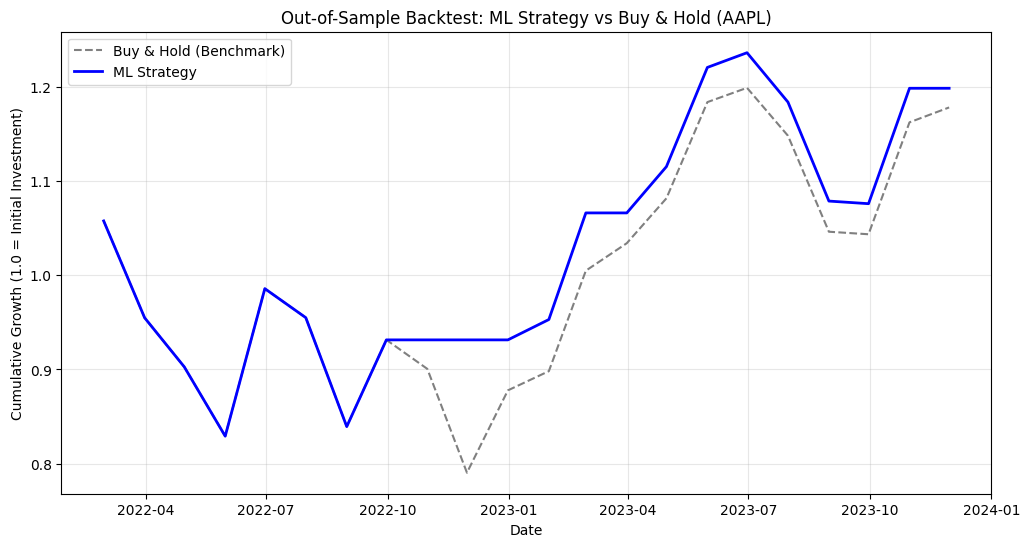


--- PERFORMANCE METRICS (TESTING PERIOD) ---
Buy & Hold Return: 17.78%
ML Strategy Return: 19.81%


In [6]:
import matplotlib.pyplot as plt
import numpy as np

print("Step 6: Backtesting the ML Strategy on Unseen Data...")

# 1. Create a clean DataFrame for our testing period
backtest_data = X_test.copy()
backtest_data['Actual_Return'] = y_test
backtest_data['Predicted_Return'] = predictions

# 2. The Trading Logic (Signal Generation)
# Predicts positive -> BUY (1)
# Predicts negative -> CASH (0)
backtest_data['Signal'] = np.where(backtest_data['Predicted_Return'] > 0, 1, 0)

# 3. Calculate Strategy Returns
# If signal is 1, we get the market return. If signal is 0, we get 0 return.
backtest_data['Strategy_Return'] = backtest_data['Signal'] * backtest_data['Actual_Return']

# 4. Calculate Cumulative Returns (Growth of a $1 investment)
backtest_data['Cumulative_Market'] = (1 + (backtest_data['Actual_Return'] / 100)).cumprod()
backtest_data['Cumulative_Strategy'] = (1 + (backtest_data['Strategy_Return'] / 100)).cumprod()

# 5. Plot the Results
plt.figure(figsize=(12, 6))
plt.plot(backtest_data.index, backtest_data['Cumulative_Market'], label='Buy & Hold (Benchmark)', color='gray', linestyle='--')
plt.plot(backtest_data.index, backtest_data['Cumulative_Strategy'], label='ML Strategy', color='blue', linewidth=2)

plt.title(f"Out-of-Sample Backtest: ML Strategy vs Buy & Hold ({target_stock})")
plt.xlabel("Date")
plt.ylabel("Cumulative Growth (1.0 = Initial Investment)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 6. Final Performance Metrics
total_market_return = (backtest_data['Cumulative_Market'].iloc[-1] - 1) * 100
total_strategy_return = (backtest_data['Cumulative_Strategy'].iloc[-1] - 1) * 100

print(f"\n--- PERFORMANCE METRICS (TESTING PERIOD) ---")
print(f"Buy & Hold Return: {total_market_return:.2f}%")
print(f"ML Strategy Return: {total_strategy_return:.2f}%")